In [72]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import stats as scipy_stats
from scipy.ndimage import gaussian_filter
import os
import time
from nba_api.stats.endpoints import (
    leaguedashplayerstats, leaguedashplayerclutch, playerawards,
    shotchartdetail, leagueseasonmatchups
)

In [73]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica Neue', 'Arial', 'DejaVu Sans'],
    'font.size': 11,
    'text.color': '#1A1A2E',
    'axes.labelcolor': '#2D3436',
    'xtick.color': '#636E72',
    'ytick.color': '#636E72',
    'axes.edgecolor': '#DFE6E9',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
})

tier_colors = {'Role': '#4C72B0', 'Star': '#DD8452', 'Olympic Gold Medalist': '#C44E52'}
tier_order = ['Role', 'Star', 'Olympic Gold Medalist']

def add_titles(fig, title, subtitle):
    fig.text(0.06, 0.98, title, fontsize=17, fontweight='bold', ha='left')
    fig.text(0.06, 0.925, subtitle, fontsize=11.5, color='#636E72', ha='left')

In [74]:
player_stats_advanced_df = pd.read_parquet('all_seasons_advanced.parquet')
player_stats_basic_df = pd.read_parquet('all_seasons_basic.parquet')
clutch_adv_df = pd.read_parquet('all_seasons_clutch.parquet')
all_awards_df = pd.read_parquet('all_awards_full.parquet')
home_clutch_df = pd.read_parquet('all_seasons_clutch_home.parquet')
road_clutch_df = pd.read_parquet('all_seasons_clutch_road.parquet')

print(f"{len(player_stats_advanced_df)} advanced, {len(player_stats_basic_df)} basic, "
      f"{len(clutch_adv_df)} clutch, {len(all_awards_df)} award rows loaded")

11059 advanced, 11059 basic, 9686 clutch, 4500 award rows loaded


In [75]:
star_descriptions = ['All-NBA', 'NBA Most Valuable Player', 'NBA Finals Most Valuable Player',
                      'NBA All-Star Most Valuable Player', 'NBA All-Star']
star_mask = all_awards_df['DESCRIPTION'].isin(star_descriptions)
star_player_ids = all_awards_df.loc[star_mask, 'PERSON_ID'].unique()

gold_mask = all_awards_df['DESCRIPTION'] == 'Olympic Gold Medal'
gold_medalist_ids = all_awards_df.loc[gold_mask, 'PERSON_ID'].unique()
olympic_gold_ids = np.intersect1d(star_player_ids, gold_medalist_ids)

print(f"{len(star_player_ids)} career stars, {len(olympic_gold_ids)} Olympic Gold Medalists")

183 career stars, 53 Olympic Gold Medalists


In [76]:
adv_cols = ['PLAYER_ID', 'PLAYER_NAME', 'TEAM_ABBREVIATION', 'AGE', 'GP', 'MIN',
            'OFF_RATING', 'DEF_RATING', 'NET_RATING', 'EFG_PCT', 'TS_PCT',
            'USG_PCT', 'PIE', 'POSS', 'SEASON']
base_cols = ['PLAYER_ID', 'FGA', 'FG3A', 'FTA', 'PTS', 'PLUS_MINUS', 'REB', 'AST', 'SEASON']

season_df = player_stats_advanced_df[adv_cols].merge(
    player_stats_basic_df[base_cols], on=['PLAYER_ID', 'SEASON'], how='inner'
)
season_df = season_df[season_df['FGA'] > 100].copy()

season_df['group'] = np.where(
    season_df['PLAYER_ID'].isin(olympic_gold_ids), 'Olympic Gold Medalist',
    np.where(season_df['PLAYER_ID'].isin(star_player_ids), 'Star', 'Role')
)
print(season_df['group'].value_counts())

group
Role                     6484
Star                     1166
Olympic Gold Medalist     612
Name: count, dtype: int64


In [77]:
clutch_cols = ['PLAYER_ID', 'SEASON', 'GP', 'MIN', 'EFG_PCT', 'TS_PCT', 'USG_PCT',
               'NET_RATING', 'PIE', 'FGA']
clutch_slim = clutch_adv_df[clutch_cols]

df = season_df.merge(clutch_slim, on=['PLAYER_ID', 'SEASON'], how='inner', suffixes=('_SEASON', '_CLUTCH'))
df = df[df['GP_CLUTCH'] >= 15].copy()
df['TS_DELTA'] = df['TS_PCT_CLUTCH'] - df['TS_PCT_SEASON']
df['USG_DELTA'] = df['USG_PCT_CLUTCH'] - df['USG_PCT_SEASON']
df['ts_quintile'] = pd.qcut(df['TS_PCT_SEASON'], q=5,
                              labels=['Bottom 20%', 'Lower-Mid', 'Middle', 'Upper-Mid', 'Top 20%'])

print(f"{len(df)} player-seasons with 15+ clutch games")

5086 player-seasons with 15+ clutch games


## Chart 1

Season vs. clutch True Shooting % for six current players (JJJ, Paolo, Giannis, Embiid, Jrue Holiday, Jalen Duren), filtered to 20+ clutch shot attempts so the drops aren't small-sample noise. A hook, not evidence — single-season numbers are volatile, and the rest of the demo tests whether this holds up over 22 years.

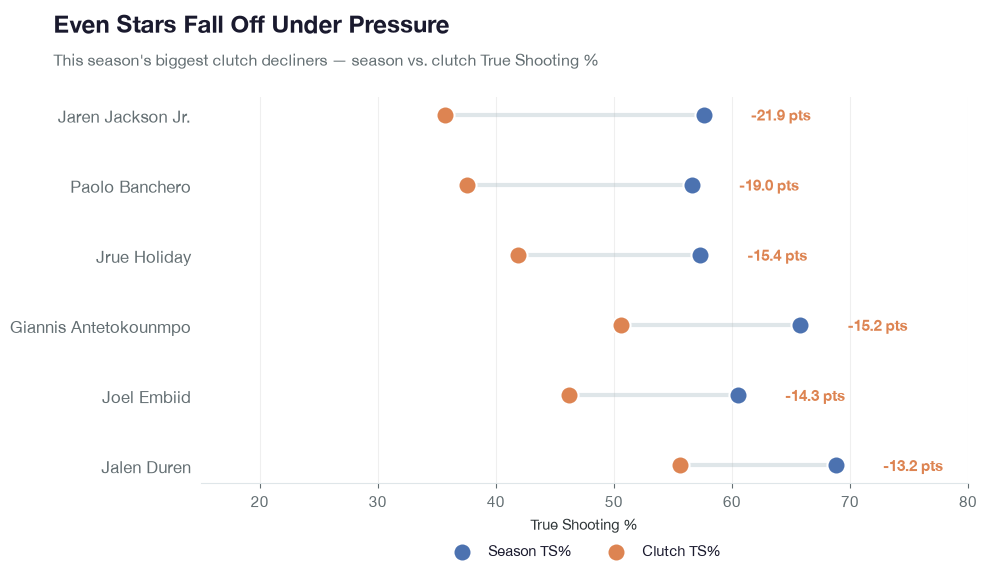

In [78]:
current_season = df[
    (df['SEASON'] == '2025-26') &
    (df['group'].isin(['Star', 'Olympic Gold Medalist'])) &
    (df['FGA_CLUTCH'] >= 20)
].copy()

hook_players = current_season.nsmallest(6, 'TS_DELTA')[
    ['PLAYER_NAME', 'TS_PCT_SEASON', 'TS_PCT_CLUTCH', 'TS_DELTA', 'FGA_CLUTCH']
]

hook_sorted = hook_players.sort_values('TS_DELTA').reset_index(drop=True)
y_pos = range(len(hook_sorted))

fig, ax = plt.subplots(figsize=(10, 6))
for y, row in zip(y_pos, hook_sorted.itertuples()):
    ax.plot([row.TS_PCT_SEASON * 100, row.TS_PCT_CLUTCH * 100], [y, y],
            color='#DFE6E9', linewidth=3, zorder=1, solid_capstyle='round')

ax.scatter(hook_sorted['TS_PCT_SEASON'] * 100, y_pos, s=170, color='#4C72B0',
           zorder=3, label='Season TS%', edgecolor='white', linewidth=1.5)
ax.scatter(hook_sorted['TS_PCT_CLUTCH'] * 100, y_pos, s=170, color='#DD8452',
           zorder=3, label='Clutch TS%', edgecolor='white', linewidth=1.5)

for y, row in zip(y_pos, hook_sorted.itertuples()):
    x_right = max(row.TS_PCT_SEASON, row.TS_PCT_CLUTCH) * 100 + 4
    ax.text(x_right, y, f'{row.TS_DELTA * 100:+.1f} pts', va='center',
            fontsize=11, fontweight='bold', color='#DD8452')

ax.set_yticks(y_pos)
ax.set_yticklabels([row.PLAYER_NAME for row in hook_sorted.itertuples()], fontsize=12)
ax.invert_yaxis()
ax.set_xlim(15, 80)
ax.set_xlabel('True Shooting %', fontsize=10.5)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.2)
ax.tick_params(left=False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False, fontsize=10.5)

add_titles(fig, 'Even Stars Fall Off Under Pressure',
           "This season's biggest clutch decliners — season vs. clutch True Shooting %")
plt.tight_layout(rect=[0, 0.05, 1, 0.9])
plt.show()

In [100]:
hook_context = current_season.nsmallest(6, 'TS_DELTA')[
    ['PLAYER_ID', 'PLAYER_NAME', 'TS_PCT_SEASON', 'TS_PCT_CLUTCH', 'TS_DELTA', 'FGA_CLUTCH']
].sort_values('TS_DELTA').reset_index(drop=True)

# Check 1: is 2025-26 an unusually hot season for them, career-wise?
career_ts = (player_stats_advanced_df[player_stats_advanced_df['PLAYER_ID'].isin(hook_context['PLAYER_ID'])]
             .groupby('PLAYER_ID')['TS_PCT'].mean().rename('CAREER_TS_PCT'))
hook_context = hook_context.merge(career_ts, on='PLAYER_ID')
hook_context['SEASON_VS_CAREER'] = (hook_context['TS_PCT_SEASON'] - hook_context['CAREER_TS_PCT']) * 100

# Check 2: is the clutch drop bigger than sample-size noise alone would predict?
hook_context['SE'] = np.sqrt(hook_context['TS_PCT_SEASON'] * (1 - hook_context['TS_PCT_SEASON']) / hook_context['FGA_CLUTCH'])
hook_context['Z_SCORE'] = hook_context['TS_DELTA'] / hook_context['SE']
hook_context['P_VALUE'] = 2 * (1 - scipy_stats.norm.cdf(np.abs(hook_context['Z_SCORE'])))

hook_context[['PLAYER_NAME', 'TS_PCT_SEASON', 'CAREER_TS_PCT', 'SEASON_VS_CAREER',
              'TS_DELTA', 'FGA_CLUTCH', 'Z_SCORE', 'P_VALUE']]

,PLAYER_NAME,TS_PCT_SEASON,CAREER_TS_PCT,SEASON_VS_CAREER,TS_DELTA,FGA_CLUTCH,Z_SCORE,P_VALUE
0,Jaren Jackson Jr.,0.576,0.575375,0.062500,-0.219,37,-2.695571,0.007027
1,Paolo Banchero,0.566,0.548000,1.800000,-0.190,80,-3.428827,0.000606
2,Jrue Holiday,0.573,0.547000,2.600000,-0.154,29,-1.676596,0.093621
3,Giannis Antetokounmpo,0.658,0.607154,5.084615,-0.152,39,-2.001013,0.045391
4,Joel Embiid,0.605,0.607600,-0.260000,-0.143,40,-1.850077,0.064302
5,Jalen Duren,0.688,0.674750,1.325000,-0.132,29,-1.534269,0.124964


## Chart 2

Each icon = 1% of all player-seasons with 100+ FGA across 22 seasons: 79% Role, 14% Star, 7% Olympic Gold Medalist. Sets the scale of "reputation" before any clutch numbers appear.

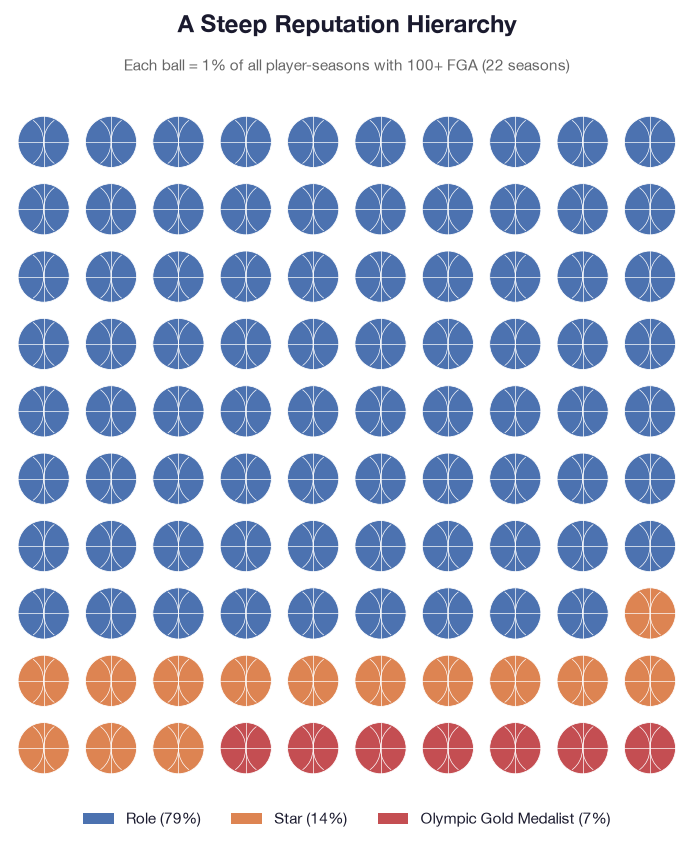

In [79]:
def draw_mini_basketball(ax, cx, cy, r, color):
    ax.add_patch(patches.Circle((cx, cy), radius=r, facecolor=color, edgecolor='white', linewidth=0.6, zorder=2))
    ax.plot([cx, cx], [cy - r, cy + r], color='white', linewidth=0.5, zorder=3)
    ax.plot([cx - r, cx + r], [cy, cy], color='white', linewidth=0.5, zorder=3)
    ax.add_patch(patches.Arc((cx - r*0.9, cy), r*1.8, r*2, theta1=300, theta2=60, color='white', linewidth=0.5, zorder=3))
    ax.add_patch(patches.Arc((cx + r*0.9, cy), r*1.8, r*2, theta1=120, theta2=240, color='white', linewidth=0.5, zorder=3))

counts = season_df['group'].value_counts()
props = (counts / counts.sum() * 100).round().astype(int)
props_ordered = {t: props[t] for t in tier_order}
props_ordered[tier_order[0]] += 100 - sum(props_ordered.values())  # absorb rounding

grid = []
for tier in tier_order:
    grid += [tier] * props_ordered[tier]

fig, ax = plt.subplots(figsize=(8, 8.5))
rows, cols = 10, 10
r = 0.38
for i, tier in enumerate(grid):
    row, col = i // cols, i % cols
    draw_mini_basketball(ax, col + 0.5, rows - 1 - row + 0.5, r, tier_colors[tier])

ax.set_xlim(0, cols)
ax.set_ylim(0, rows)
ax.set_aspect('equal')
ax.axis('off')

legend_handles = [patches.Patch(facecolor=tier_colors[t], label=f'{t} ({props_ordered[t]}%)') for t in tier_order]
ax.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=False, fontsize=11)

fig.text(0.5, 0.97, 'A Steep Reputation Hierarchy', fontsize=17, fontweight='bold', ha='center')
fig.text(0.5, 0.925, 'Each ball = 1% of all player-seasons with 100+ FGA (22 seasons)',
          fontsize=11, color='#666666', ha='center')

plt.tight_layout(rect=[0, 0.03, 1, 0.9])
plt.show()

## Chart 3

Five season-long metrics by tier — TS%, EFG%, Usage%, Net Rating, PIE. Stars lead on all five, not just shooting, which rules out "stars aren't actually better" as an explanation for anything that follows.

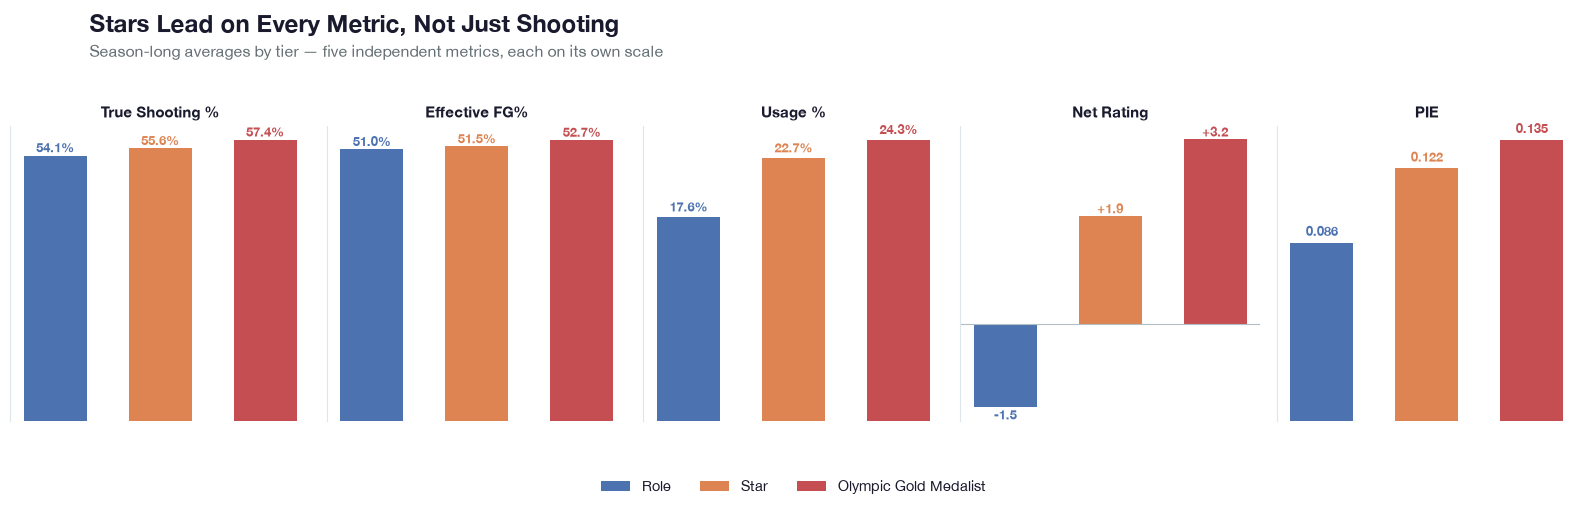

In [96]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4.5))

metric_specs = [
    ('TS_PCT', 'True Shooting %', lambda v: f'{v*100:.1f}%'),
    ('EFG_PCT', 'Effective FG%', lambda v: f'{v*100:.1f}%'),
    ('USG_PCT', 'Usage %', lambda v: f'{v*100:.1f}%'),
    ('NET_RATING', 'Net Rating', lambda v: f'{v:+.1f}'),
    ('PIE', 'PIE', lambda v: f'{v:.3f}'),
]

for ax, (metric, label, fmt) in zip(axes, metric_specs):
    vals = tier_means[metric].reindex(tier_order)
    bars = ax.bar(range(3), vals, color=[tier_colors[t] for t in tier_order], width=0.6)

    for bar, tier in zip(bars, tier_order):
        v = tier_means.loc[tier, metric]
        y_offset = (vals.max() - vals.min()) * 0.04 if vals.min() >= 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2, v + y_offset if v >= 0 else v - y_offset,
                fmt(v), ha='center', va='bottom' if v >= 0 else 'top', fontsize=9,
                fontweight='bold', color=tier_colors[tier])

    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks([])
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    if metric == 'NET_RATING':
        ax.axhline(0, color='#B2BEC3', linewidth=0.8)
    ax.set_yticks([])

legend_handles = [patches.Patch(facecolor=tier_colors[t], label=t) for t in tier_order]
fig.legend(handles=legend_handles, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=3, frameon=False, fontsize=10.5)

add_titles(fig, 'Stars Lead on Every Metric, Not Just Shooting',
           'Season-long averages by tier — five independent metrics, each on its own scale')

plt.tight_layout(rect=[0, 0.08, 1, 0.86])
plt.show()

## Chart 4

*Sub-question: does clutch efficiency match season efficiency?* All tiers decline (Role −0.6, Star −1.3, Olympic Gold Medalist −1.1 pts). Not a clean ladder — Olympic Gold Medalist declines less than Star, worth saying plainly.

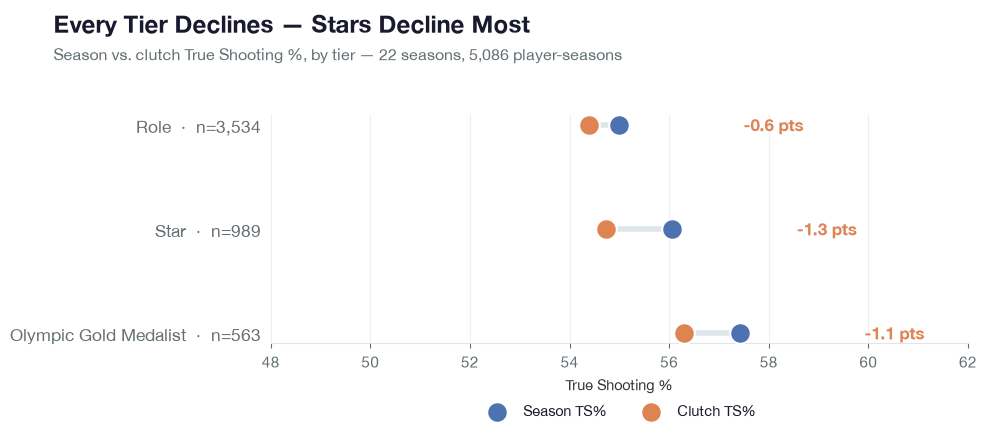

In [81]:
tier_ts = df.groupby('group')[['TS_PCT_SEASON', 'TS_PCT_CLUTCH']].mean().reindex(tier_order)
tier_ts['TS_DELTA'] = tier_ts['TS_PCT_CLUTCH'] - tier_ts['TS_PCT_SEASON']
tier_counts = df['group'].value_counts().reindex(tier_order)

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(tier_order))

for y, tier in zip(y_pos, tier_order):
    row = tier_ts.loc[tier]
    ax.plot([row['TS_PCT_SEASON'] * 100, row['TS_PCT_CLUTCH'] * 100], [y, y],
            color='#DFE6E9', linewidth=4, zorder=1, solid_capstyle='round')

ax.scatter(tier_ts['TS_PCT_SEASON'] * 100, y_pos, s=220, color='#4C72B0',
           zorder=3, label='Season TS%', edgecolor='white', linewidth=1.5)
ax.scatter(tier_ts['TS_PCT_CLUTCH'] * 100, y_pos, s=220, color='#DD8452',
           zorder=3, label='Clutch TS%', edgecolor='white', linewidth=1.5)

for y, tier in zip(y_pos, tier_order):
    row = tier_ts.loc[tier]
    x_right = max(row['TS_PCT_SEASON'], row['TS_PCT_CLUTCH']) * 100 + 2.5
    ax.text(x_right, y, f"{row['TS_DELTA'] * 100:+.1f} pts", va='center',
            fontsize=12.5, fontweight='bold', color='#DD8452')

labels = [f"{t}  ·  n={tier_counts[t]:,}" for t in tier_order]
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=12.5)
ax.invert_yaxis()
ax.set_xlim(48, 62)
ax.set_xlabel('True Shooting %', fontsize=10.5)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.2)
ax.tick_params(left=False)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2, frameon=False, fontsize=10.5)

add_titles(fig, 'Every Tier Declines — Stars Decline Most',
           'Season vs. clutch True Shooting %, by tier — 22 seasons, 5,086 player-seasons')
plt.tight_layout(rect=[0, 0.1, 1, 0.85])
plt.show()

## Chart 5

Usage change vs. TS% change, by tier. The core mechanism: Role loses the most usage while shooting holds up best; Olympic Gold Medalist gains usage even as shooting declines. Who gets the ball tracks reputation more than current performance.

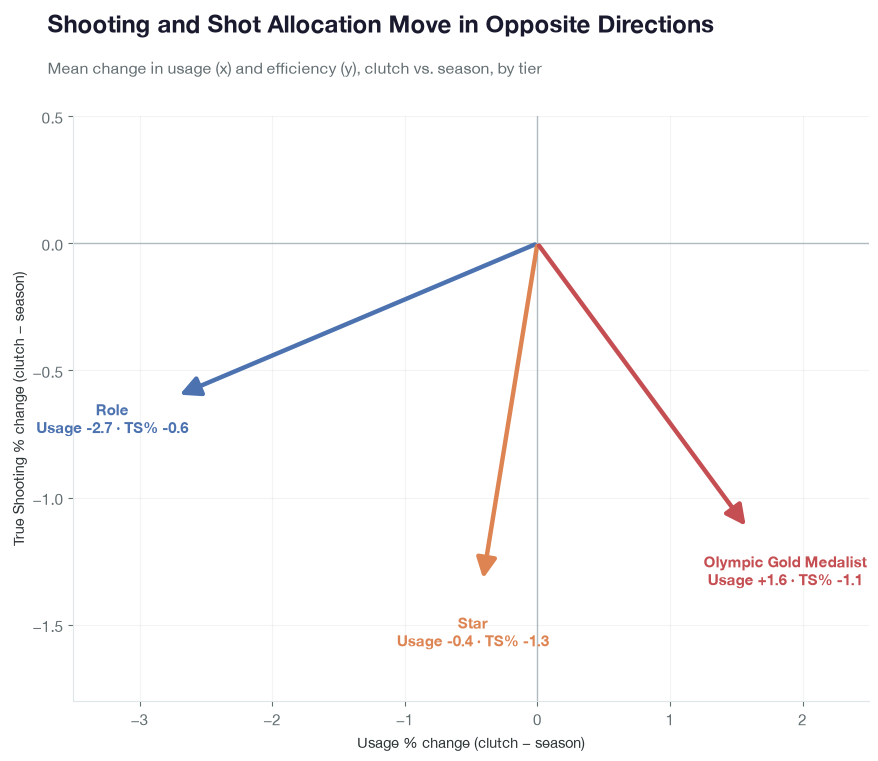

In [82]:
tier_deltas = df.groupby('group')[['TS_DELTA', 'USG_DELTA']].mean().reindex(tier_order)

fig, ax = plt.subplots(figsize=(9, 7.5))
ax.axhline(0, color='#B2BEC3', linewidth=1, zorder=1)
ax.axvline(0, color='#B2BEC3', linewidth=1, zorder=1)

for tier in tier_order:
    dx = tier_deltas.loc[tier, 'USG_DELTA'] * 100
    dy = tier_deltas.loc[tier, 'TS_DELTA'] * 100
    ax.annotate('', xy=(dx, dy), xytext=(0, 0),
                arrowprops=dict(arrowstyle='-|>', color=tier_colors[tier],
                                 linewidth=3.2, mutation_scale=30), zorder=3)
    ax.annotate(f'{tier}\nUsage {dx:+.1f} · TS% {dy:+.1f}',
                (dx * 1.18, dy * 1.15), ha='center', va='center', fontsize=10.5,
                fontweight='bold', color=tier_colors[tier])

ax.set_xlim(-3.5, 2.5)
ax.set_ylim(-1.8, 0.5)
ax.set_xlabel('Usage % change (clutch − season)', fontsize=10.5)
ax.set_ylabel('True Shooting % change (clutch − season)', fontsize=10.5)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=0.15)

add_titles(fig, 'Shooting and Shot Allocation Move in Opposite Directions',
           'Mean change in usage (x) and efficiency (y), clutch vs. season, by tier')
plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

In [83]:
top_clutch_volume = (
    df.sort_values('FGA_CLUTCH', ascending=False)
    .groupby('group')
    .head(15)
    [['PLAYER_ID', 'PLAYER_NAME', 'SEASON', 'group', 'FGA_CLUTCH']]
)
print(top_clutch_volume['group'].value_counts())

group
Olympic Gold Medalist    15
Star                     15
Role                     15
Name: count, dtype: int64


In [84]:
def fetch_shots(player_season_list, point_diff, cache_path):
    if os.path.exists(cache_path):
        out_df = pd.read_parquet(cache_path)
        print(f"Loaded {len(out_df)} shot rows from cache")
        return out_df

    frames = []
    for i, row in enumerate(player_season_list.itertuples(), start=1):
        try:
            params = dict(player_id=row.PLAYER_ID, team_id=0, season_nullable=row.SEASON,
                          season_type_all_star='Regular Season', context_measure_simple='FGA')
            if point_diff is not None:
                params['point_diff_nullable'] = point_diff
            shots = shotchartdetail.ShotChartDetail(**params).get_data_frames()[0]
            shots['PLAYER_ID'] = row.PLAYER_ID
            shots['SEASON'] = row.SEASON
            shots['group'] = row.group
            frames.append(shots)
        except Exception as e:
            print(f"failed for {row.PLAYER_NAME} ({row.SEASON}): {e}")
        print(f"{i}/{len(player_season_list)} pulled ({row.PLAYER_NAME}, {row.SEASON})")
        time.sleep(0.6)

    out_df = pd.concat(frames, ignore_index=True)
    out_df.to_parquet(cache_path)
    return out_df

season_shots_df = fetch_shots(top_clutch_volume, None, 'shot_selection_season.parquet')
close_game_shots_df = fetch_shots(top_clutch_volume, 5, 'shot_selection_closegame.parquet')

Loaded 65674 shot rows from cache
Loaded 34686 shot rows from cache


In [85]:
true_clutch_shots = close_game_shots_df[
    (close_game_shots_df['PERIOD'] >= 4) &
    (close_game_shots_df['MINUTES_REMAINING'] < 5)
].copy()

print(f"{len(season_shots_df)} season shots, {len(close_game_shots_df)} close-game shots, "
      f"{len(true_clutch_shots)} true clutch shots")
print(true_clutch_shots.groupby('group').size())

65674 season shots, 34686 close-game shots, 5528 true clutch shots
group
Olympic Gold Medalist    2114
Role                     1574
Star                     1840
dtype: int64


## Chart 6

*Sub-question: does shot selection shift under pressure?*  Stars shift toward the rim, Olympic Gold Medalists shift toward threes, Role shifts away from mid-range. The only chart where tiers move in different directions.

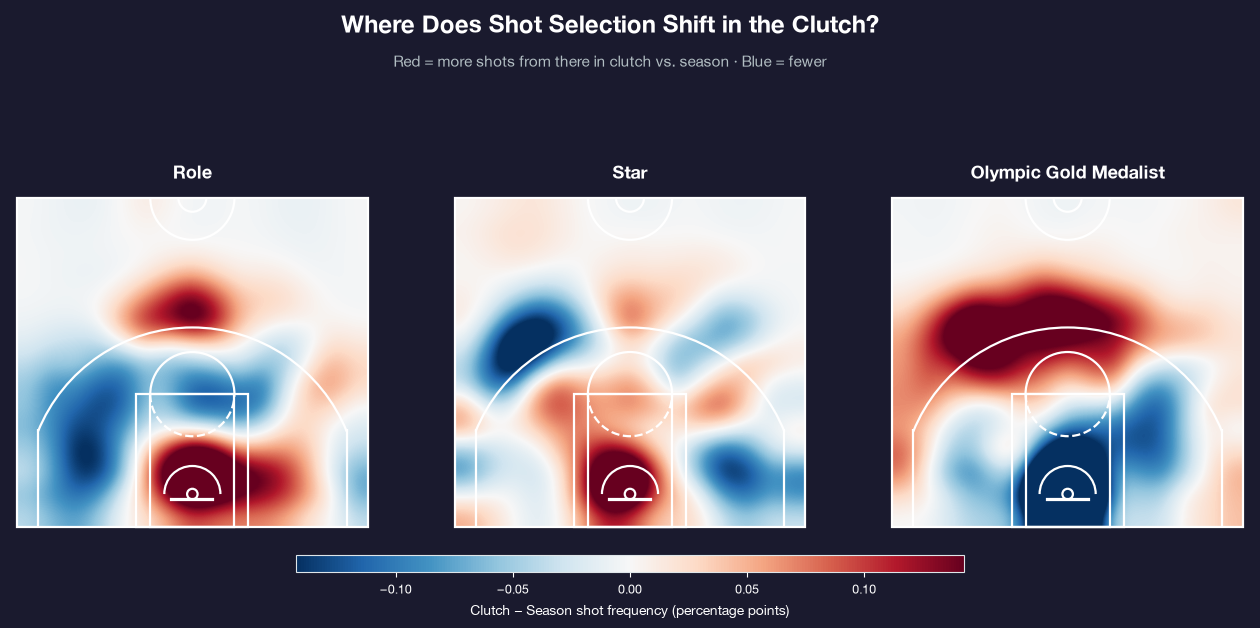

In [86]:
def draw_court(ax, color='white', lw=1.6):
    elements = [
        patches.Circle((0, 0), radius=7.5, linewidth=lw, color=color, fill=False),
        patches.Rectangle((-30, -7.5), 60, -1, linewidth=lw, color=color),
        patches.Rectangle((-80, -47.5), 160, 190, linewidth=lw, color=color, fill=False),
        patches.Rectangle((-60, -47.5), 120, 190, linewidth=lw, color=color, fill=False),
        patches.Arc((0, 142.5), 120, 120, theta1=0, theta2=180, linewidth=lw, color=color),
        patches.Arc((0, 142.5), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color, linestyle='dashed'),
        patches.Arc((0, 0), 80, 80, theta1=0, theta2=180, linewidth=lw, color=color),
        patches.Rectangle((-220, -47.5), 0, 140, linewidth=lw, color=color),
        patches.Rectangle((220, -47.5), 0, 140, linewidth=lw, color=color),
        patches.Arc((0, 0), 475, 475, theta1=22, theta2=158, linewidth=lw, color=color),
        patches.Arc((0, 422.5), 120, 120, theta1=180, theta2=360, linewidth=lw, color=color),
        patches.Arc((0, 422.5), 40, 40, theta1=180, theta2=360, linewidth=lw, color=color),
        patches.Rectangle((-250, -47.5), 500, 470, linewidth=lw, color=color, fill=False),
    ]
    for el in elements:
        ax.add_patch(el)

xedges = np.linspace(-250, 250, 16)
yedges = np.linspace(-47.5, 422.5, 16)

fig, axes = plt.subplots(1, 3, figsize=(16, 6.2))
fig.patch.set_facecolor('#1A1A2E')

diffs = {}
for tier in tier_order:
    s = season_shots_df[season_shots_df['group'] == tier]
    c = true_clutch_shots[true_clutch_shots['group'] == tier]
    s_hist, _, _ = np.histogram2d(s['LOC_X'], s['LOC_Y'], bins=[xedges, yedges])
    c_hist, _, _ = np.histogram2d(c['LOC_X'], c['LOC_Y'], bins=[xedges, yedges])
    diff = (c_hist / c_hist.sum() - s_hist / s_hist.sum()) * 100
    diffs[tier] = gaussian_filter(diff, sigma=0.9)

vmax = np.percentile(np.abs(np.concatenate([d.ravel() for d in diffs.values()])), 92)

for ax, tier in zip(axes, tier_order):
    ax.set_facecolor('#1A1A2E')
    im = ax.imshow(diffs[tier].T, origin='lower', extent=[-250, 250, -47.5, 422.5],
                    cmap='RdBu_r', vmin=-vmax, vmax=vmax, interpolation='bicubic')
    draw_court(ax, color='white')
    ax.set_xlim(-260, 260)
    ax.set_ylim(-60, 430)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(tier, color='white', fontsize=13, fontweight='bold', pad=10)

cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.035, pad=0.04, aspect=40)
cbar.set_label('Clutch − Season shot frequency (percentage points)', color='white', fontsize=10)
cbar.ax.xaxis.set_tick_params(color='white', labelsize=9)
plt.setp(plt.getp(cbar.ax.axes, 'xticklabels'), color='white')

fig.text(0.5, 0.98, 'Where Does Shot Selection Shift in the Clutch?', fontsize=17,
          fontweight='bold', ha='center', color='white')
fig.text(0.5, 0.925, 'Red = more shots from there in clutch vs. season · Blue = fewer',
          fontsize=11, color='#B2BEC3', ha='center')

plt.savefig('shot_selection_court.png', dpi=130, bbox_inches='tight', facecolor='#1A1A2E')
plt.show()

In [87]:
sample_sizes = {'Role': 269, 'Star': 70, 'Olympic Gold Medalist': 106}

matchup_sample = pd.concat([
    df[df['group'] == tier].sort_values('FGA_CLUTCH', ascending=False).head(n)
    for tier, n in sample_sizes.items()
])[['PLAYER_ID', 'PLAYER_NAME', 'SEASON', 'group', 'FGA_CLUTCH']]

print(matchup_sample['group'].value_counts())

group
Role                     269
Olympic Gold Medalist    106
Star                      70
Name: count, dtype: int64


In [88]:
def fetch_primary_defenders(player_season_list, cache_path):
    if os.path.exists(cache_path):
        out_df = pd.read_parquet(cache_path)
        print(f"Loaded {len(out_df)} rows from cache")
        return out_df

    results = []
    for i, row in enumerate(player_season_list.itertuples(), start=1):
        try:
            matchups = leagueseasonmatchups.LeagueSeasonMatchups(
                season=row.SEASON, off_player_id_nullable=row.PLAYER_ID
            ).get_data_frames()[0]
            if not matchups.empty:
                top = matchups.sort_values('MATCHUP_TIME_SEC', ascending=False).iloc[0]
                results.append({
                    'PLAYER_ID': row.PLAYER_ID, 'PLAYER_NAME': row.PLAYER_NAME,
                    'SEASON': row.SEASON, 'group': row.group,
                    'DEF_PLAYER_ID': top['DEF_PLAYER_ID'], 'DEF_PLAYER_NAME': top['DEF_PLAYER_NAME'],
                    'MATCHUP_MIN': top['MATCHUP_MIN']
                })
        except Exception as e:
            print(f"failed for {row.PLAYER_NAME}: {e}")
        print(f"{i}/{len(player_season_list)} pulled")
        time.sleep(0.6)

    out_df = pd.DataFrame(results)
    out_df.to_parquet(cache_path)
    return out_df

primary_defenders_df = fetch_primary_defenders(matchup_sample, 'primary_defenders_v2.parquet')
print(f"{len(primary_defenders_df)} defenders matched")

Loaded 163 rows from cache
163 defenders matched


In [89]:
defender_quality = player_stats_advanced_df[['PLAYER_ID', 'SEASON', 'DEF_RATING']].rename(
    columns={'PLAYER_ID': 'DEF_PLAYER_ID', 'DEF_RATING': 'DEFENDER_DEF_RATING'}
)

matchup_analysis = primary_defenders_df.merge(defender_quality, on=['DEF_PLAYER_ID', 'SEASON'], how='left')
matchup_analysis = matchup_analysis.merge(
    df[['PLAYER_ID', 'SEASON', 'TS_DELTA']], on=['PLAYER_ID', 'SEASON'], how='inner'
)
matchup_analysis = matchup_analysis.dropna(subset=['DEFENDER_DEF_RATING'])

print(f"{len(matchup_analysis)} total rows")
print(matchup_analysis['group'].value_counts())

corr_stats = {}
for tier in tier_order:
    sub = matchup_analysis[matchup_analysis['group'] == tier]
    r, p = scipy_stats.pearsonr(sub['DEFENDER_DEF_RATING'], sub['TS_DELTA'])
    corr_stats[tier] = (r, p)
    print(f"{tier}: r={r:.2f}, p={p:.3f}, n={len(sub)}")

163 total rows
group
Role                     84
Olympic Gold Medalist    44
Star                     35
Name: count, dtype: int64
Role: r=-0.01, p=0.893, n=84
Star: r=-0.18, p=0.294, n=35
Olympic Gold Medalist: r=0.08, p=0.584, n=44


## Chart 7

*Sub-question: is underperformance matchup-driven?* Primary defender quality vs. clutch TS% change, by tier — none of the three correlations are significant. A clean, honest null result.

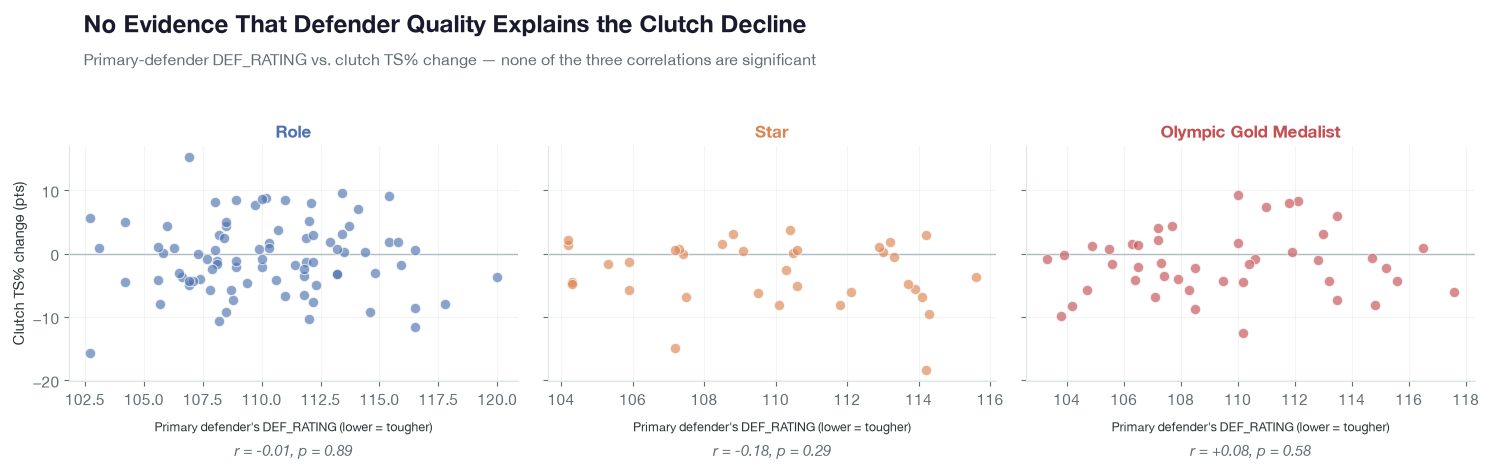

In [90]:
stats_text = {tier: f'r = {corr_stats[tier][0]:+.2f}, p = {corr_stats[tier][1]:.2f}' for tier in tier_order}

fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)

for ax, tier in zip(axes, tier_order):
    sub = matchup_analysis[matchup_analysis['group'] == tier]
    ax.scatter(sub['DEFENDER_DEF_RATING'], sub['TS_DELTA'] * 100, s=55,
               color=tier_colors[tier], alpha=0.65, edgecolor='white', linewidth=0.8)
    ax.axhline(0, color='#B2BEC3', linewidth=1, zorder=0)

    ax.set_title(tier, fontsize=12.5, fontweight='bold', color=tier_colors[tier])
    ax.set_xlabel("Primary defender's DEF_RATING (lower = tougher)", fontsize=9, labelpad=8)
    ax.text(0.5, -0.32, stats_text[tier], transform=ax.transAxes, ha='center',
            fontsize=10.5, color='#636E72', style='italic')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.15)

axes[0].set_ylabel('Clutch TS% change (pts)', fontsize=10.5)

add_titles(fig, 'No Evidence That Defender Quality Explains the Clutch Decline',
           'Primary-defender DEF_RATING vs. clutch TS% change — none of the three correlations are significant')

plt.tight_layout(rect=[0, 0.12, 1, 0.86])
plt.show()

In [91]:
hr_cols = ['PLAYER_ID', 'SEASON', 'GP', 'TS_PCT', 'NET_RATING', 'USG_PCT']

hr = (home_clutch_df[hr_cols]
      .merge(road_clutch_df[hr_cols], on=['PLAYER_ID', 'SEASON'], suffixes=('_HOME', '_ROAD')))
hr = hr[(hr['GP_HOME'] >= 8) & (hr['GP_ROAD'] >= 8)].copy()
hr = hr.merge(df[['PLAYER_ID', 'SEASON', 'PLAYER_NAME', 'group']], on=['PLAYER_ID', 'SEASON'], how='inner')

hr['TS_GAP'] = (hr['TS_PCT_HOME'] - hr['TS_PCT_ROAD']) * 100
hr['NET_GAP'] = hr['NET_RATING_HOME'] - hr['NET_RATING_ROAD']

tier_gaps = hr.groupby('group')[['TS_GAP', 'NET_GAP']].mean().reindex(tier_order)
hr_counts = hr['group'].value_counts().reindex(tier_order)
print(f"{len(hr)} player-seasons with 8+ clutch games home and road")
tier_gaps

4382 player-seasons with 8+ clutch games home and road


,TS_GAP,NET_GAP
group,,
Role,1.598874,8.383072
Star,1.532321,8.841540
Olympic Gold Medalist,2.612830,7.903208


## Chart 8

*Sub-question: do home/road splits matter?* Yes, but similarly across all tiers (TS% and Net Rating both agree). Rules out venue as the reason stars decline more than role players.

/var/folders/vp/pg9__5w51d35qj0z3gpg0dlm0000gn/T/ipykernel_60263/2231015094.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([f'{t}\n(n={hr_counts[t]})' for t in tier_order], fontsize=10.5)
/var/folders/vp/pg9__5w51d35qj0z3gpg0dlm0000gn/T/ipykernel_60263/2231015094.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_yticklabels([f'{t}\n(n={hr_counts[t]})' for t in tier_order], fontsize=10.5)


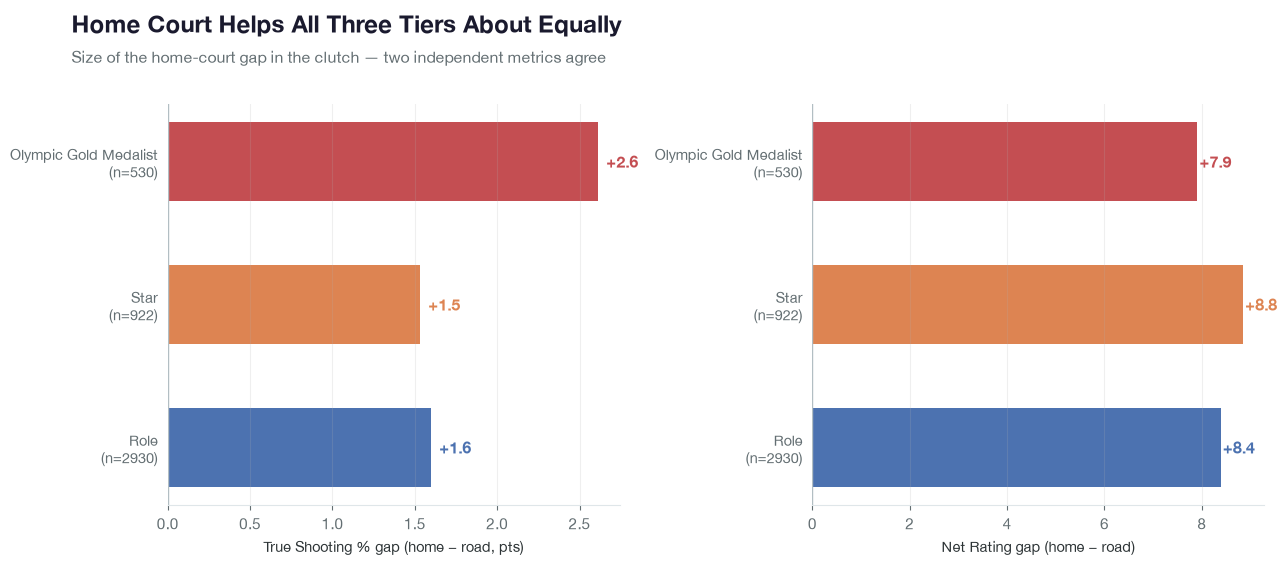

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

panels = [('TS_GAP', 'True Shooting % gap (home − road, pts)', axes[0]),
          ('NET_GAP', 'Net Rating gap (home − road)', axes[1])]

for col, xlabel, ax in panels:
    bars = ax.barh(tier_order, tier_gaps[col], color=[tier_colors[t] for t in tier_order], height=0.55)
    for bar, tier in zip(bars, tier_order):
        val = tier_gaps.loc[tier, col]
        ax.text(val + (0.05 if val >= 0 else -0.05), bar.get_y() + bar.get_height()/2,
                f'{val:+.1f}', va='center', ha='left' if val >= 0 else 'right',
                fontsize=11.5, fontweight='bold', color=tier_colors[tier])

    ax.set_xlabel(xlabel, fontsize=10.5)
    ax.set_yticklabels([f'{t}\n(n={hr_counts[t]})' for t in tier_order], fontsize=10.5)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.grid(axis='x', alpha=0.2)
    ax.tick_params(left=False)
    ax.axvline(0, color='#B2BEC3', linewidth=1)

add_titles(fig, 'Home Court Helps All Three Tiers About Equally',
           'Size of the home-court gap in the clutch — two independent metrics agree')
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

## Chart 9

22-year trend by tier. Olympic Gold Medalist shows a real downward trend (p=0.042); Role shows a step-change after 2011-12 (p=0.008) but no steady trend; Star shows neither. Not uniform across eras — treat as suggestive, not conclusive (multiple tests, no correction).

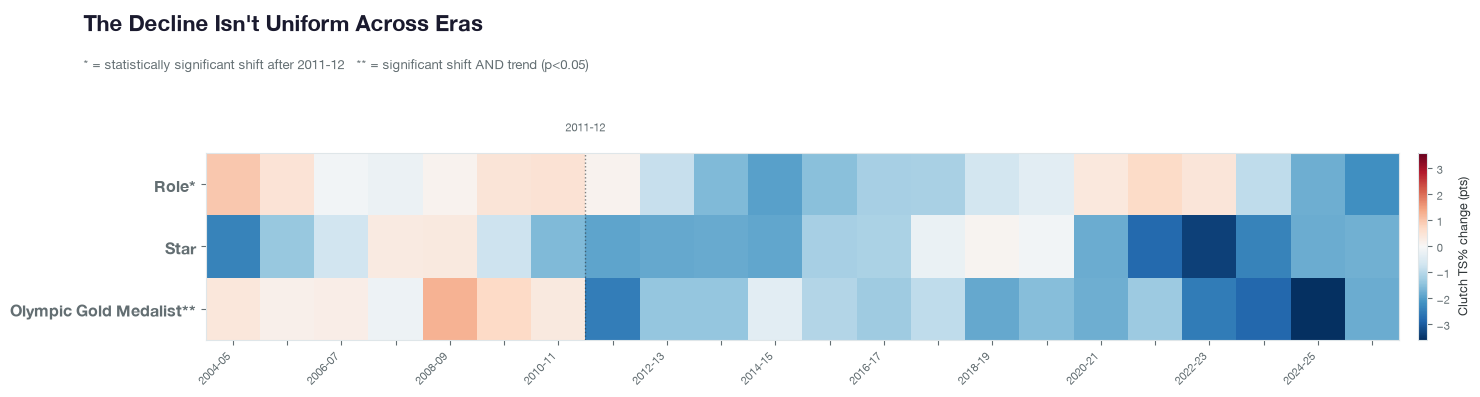

In [99]:
fig, ax = plt.subplots(figsize=(15, 3.8))
vmax = np.abs(smoothed.values).max()
im = ax.imshow(smoothed.values, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)

sig_marks = {'Role': '*', 'Star': '', 'Olympic Gold Medalist': '**'}
ax.set_yticks(range(len(tier_order)))
ax.set_yticklabels([f'{t}{sig_marks[t]}' for t in tier_order], fontsize=11.5, fontweight='bold')

ax.set_xticks(range(len(season_order)))
xlabels = [s if i % 2 == 0 else '' for i, s in enumerate(season_order)]
ax.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=8)

split_idx = season_order.index('2011-12')
ax.axvline(split_idx - 0.5, color='#2D3436', linewidth=1, linestyle=':', alpha=0.6)
ax.text(split_idx - 0.5, -0.85, '2011-12', ha='center', fontsize=8, color='#636E72')

cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.02, pad=0.015)
cbar.set_label('Clutch TS% change (pts)', fontsize=9)
cbar.ax.tick_params(labelsize=8)

fig.text(0.06, 0.98, "The Decline Isn't Uniform Across Eras", fontsize=16, fontweight='bold', ha='left')
fig.text(0.06, 0.88, '* = statistically significant shift after 2011-12   ** = significant shift AND trend (p<0.05)',
          fontsize=9.5, color='#636E72', ha='left')

plt.tight_layout(rect=[0, 0, 1, 0.82])
plt.show()

## Chart 10

Closing scoreboard restating Chart 5's numbers. Thesis: stars are genuinely better, but in the clutch, who gets the ball tracks reputation more than who's actually shooting well right now.

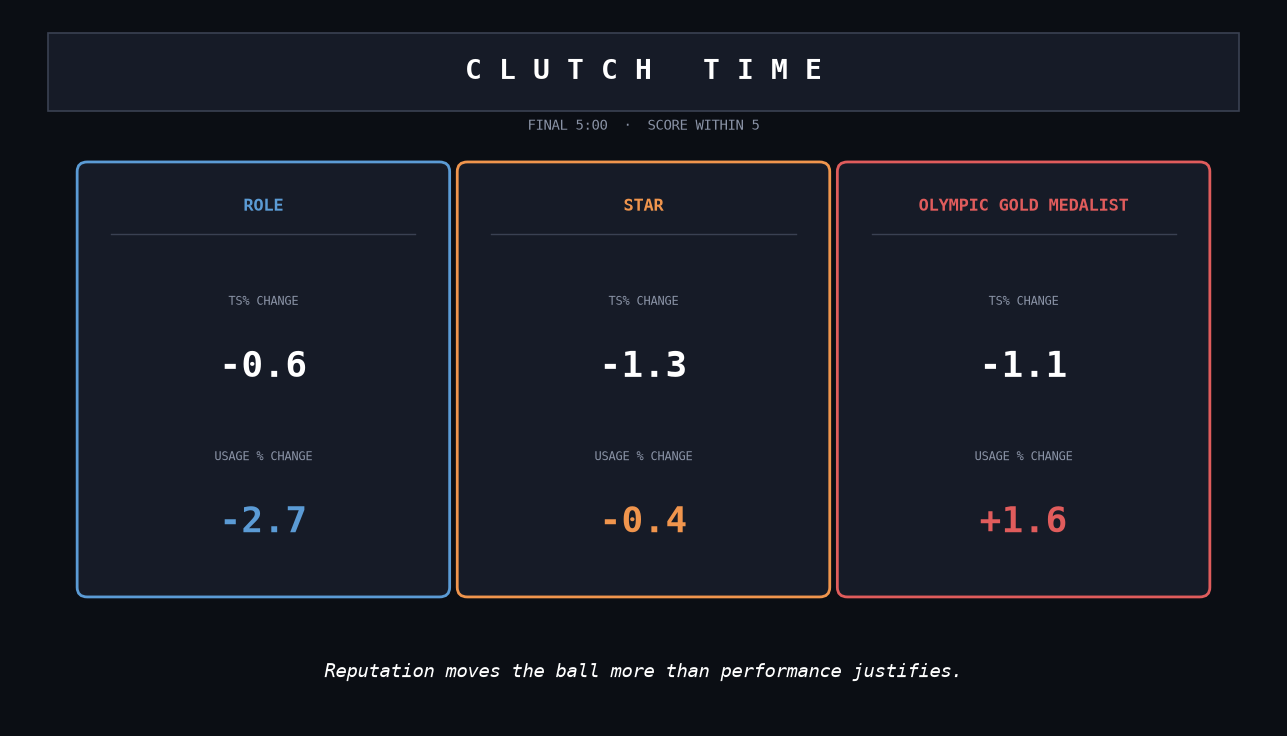

In [95]:
scoreboard_colors = {'Role': '#5B9BD5', 'Star': '#F0954D', 'Olympic Gold Medalist': '#E05C5C'}

fig, ax = plt.subplots(figsize=(13, 7.5))
fig.patch.set_facecolor('#0B0E14')
ax.set_facecolor('#0B0E14')
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

header = patches.Rectangle((0.3, 5.15), 9.4, 0.65, facecolor='#161B27', edgecolor='#3A4152', linewidth=1.2)
ax.add_patch(header)
ax.text(5, 5.475, 'C L U T C H   T I M E', fontsize=20, fontweight='bold', color='white',
        ha='center', va='center', fontfamily='monospace')
ax.text(5, 5.02, 'FINAL 5:00  ·  SCORE WITHIN 5', fontsize=10, color='#8A93A6',
        ha='center', va='center', fontfamily='monospace')

panel_w = 2.9
gaps = [0.55, 3.55, 6.55]
for gx, tier in zip(gaps, tier_order):
    ts_val = tier_deltas.loc[tier, 'TS_DELTA'] * 100
    usg_val = tier_deltas.loc[tier, 'USG_DELTA'] * 100

    panel = patches.FancyBboxPatch((gx, 1.1), panel_w, 3.6, boxstyle="round,pad=0.02,rounding_size=0.08",
                                     facecolor='#161B27', edgecolor=scoreboard_colors[tier], linewidth=2)
    ax.add_patch(panel)

    ax.text(gx + panel_w/2, 4.35, tier.upper(), fontsize=12.5, fontweight='bold',
            color=scoreboard_colors[tier], ha='center', va='center', fontfamily='monospace')
    ax.plot([gx+0.25, gx+panel_w-0.25], [4.12, 4.12], color='#3A4152', linewidth=1)

    ax.text(gx + panel_w/2, 3.55, 'TS% CHANGE', fontsize=8.5, color='#8A93A6',
            ha='center', va='center', fontfamily='monospace')
    ax.text(gx + panel_w/2, 3.0, f"{ts_val:+.1f}", fontsize=26, fontweight='bold',
            color='white', ha='center', va='center', fontfamily='monospace')

    ax.text(gx + panel_w/2, 2.25, 'USAGE % CHANGE', fontsize=8.5, color='#8A93A6',
            ha='center', va='center', fontfamily='monospace')
    ax.text(gx + panel_w/2, 1.7, f"{usg_val:+.1f}", fontsize=26, fontweight='bold',
            color=scoreboard_colors[tier], ha='center', va='center', fontfamily='monospace')

ax.text(5, 0.45, 'Reputation moves the ball more than performance justifies.',
        fontsize=13.5, color='white', ha='center', va='center', style='italic', fontfamily='monospace')

plt.tight_layout()
plt.savefig('closing_scoreboard.png', dpi=130, bbox_inches='tight', facecolor='#0B0E14')
plt.show()